ERROR: Could not find a version that satisfies the requirement matplotli (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for matplotli


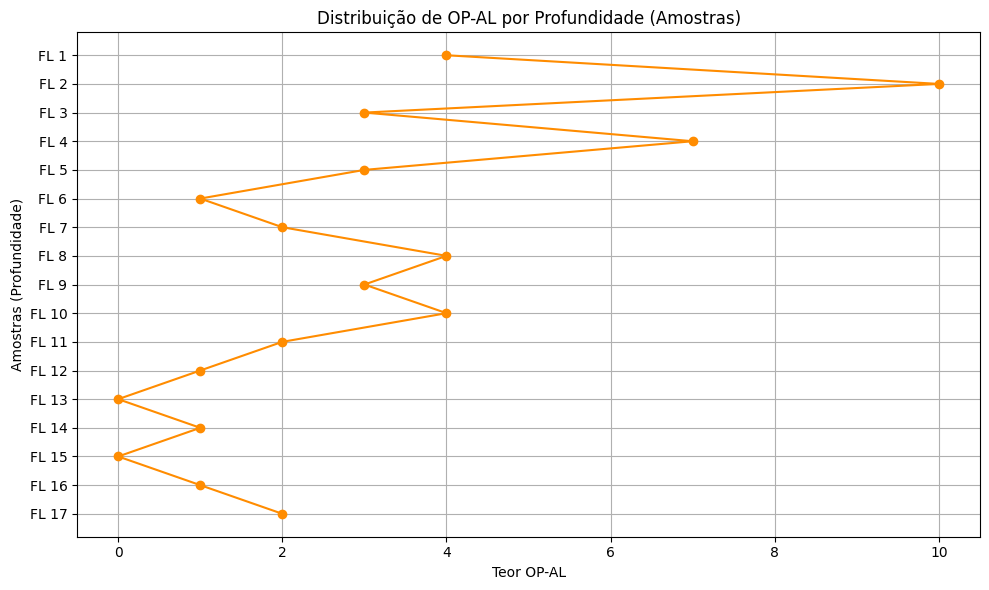

In [15]:
!python -m pip install matplotli

import matplotlib.pyplot as plt

amostras = [
    "FL 1", "FL 2", "FL 3", "FL 4", "FL 5", "FL 6", "FL 7", "FL 8", "FL 9",
    "FL 10", "FL 11", "FL 12", "FL 13", "FL 14", "FL 15", "FL 16", "FL 17"
]
op_al = [4, 10, 3, 7, 3, 1, 2, 4, 3, 4, 2, 1, 0, 1, 0, 1, 2]

plt.figure(figsize=(10, 6))
plt.plot(op_al, amostras, marker='o', linestyle='-', color='darkorange')
plt.xlabel('Teor OP-AL')
plt.ylabel('Amostras (Profundidade)')
plt.title('Distribuição de OP-AL por Profundidade (Amostras)')
plt.grid(True)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


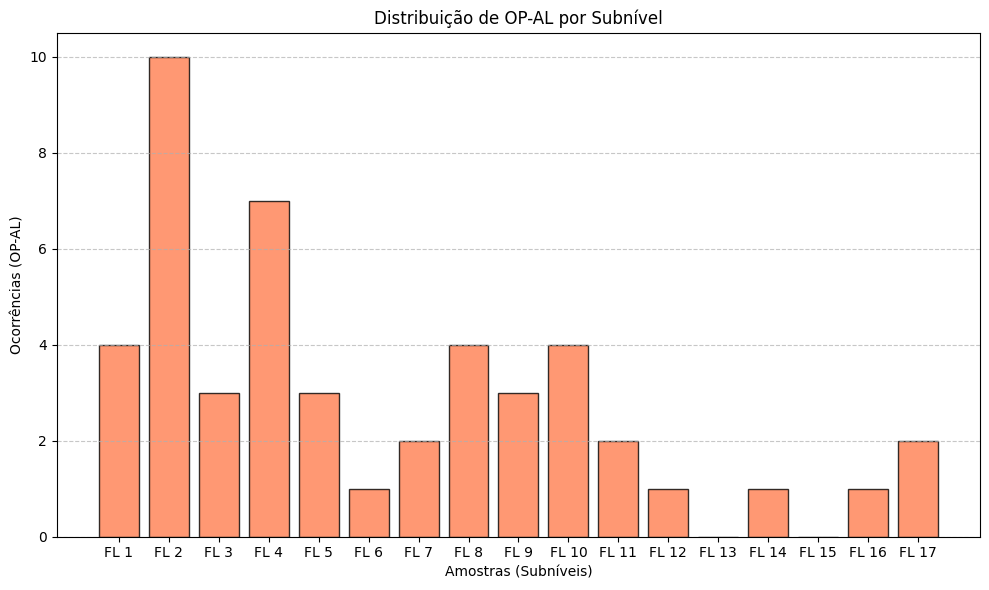

In [16]:
# Dados
amostras = [
    "FL 1", "FL 2", "FL 3", "FL 4", "FL 5", "FL 6", "FL 7", "FL 8", "FL 9",
    "FL 10", "FL 11", "FL 12", "FL 13", "FL 14", "FL 15", "FL 16", "FL 17"
]
op_al = [4, 10, 3, 7, 3, 1, 2, 4, 3, 4, 2, 1, 0, 1, 0, 1, 2]

# Gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(amostras, op_al, color='coral', edgecolor='black', alpha=0.8)
plt.xlabel('Amostras (Subníveis)')
plt.ylabel('Ocorrências (OP-AL)')
plt.title('Distribuição de OP-AL por Subnível')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


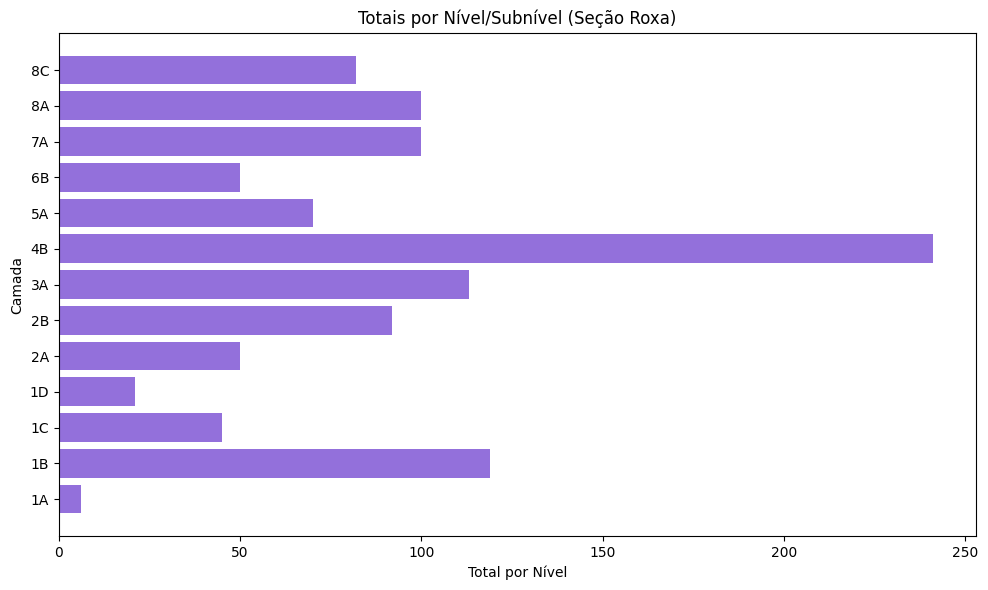

In [17]:
!python -m pip install pandas

import pandas as pd
import matplotlib.pyplot as plt

# Simulação de dados da seção roxa (substitua com os dados reais conforme necessário)
dados_roxos = {
    'Camada': ['8C', '8A', '7A', '6B', '5A', '4B', '3A', '2B', '2A', '1D', '1C', '1B', '1A'],
    'Total por nível': [82, 100, 100, 50, 70, 241, 113, 92, 50, 21, 45, 119, 6],
}

df_roxo = pd.DataFrame(dados_roxos)

# Gráfico
plt.figure(figsize=(10, 6))
plt.barh(df_roxo['Camada'], df_roxo['Total por nível'], color='mediumpurple')
plt.xlabel('Total por Nível')
plt.ylabel('Camada')
plt.title('Totais por Nível/Subnível (Seção Roxa)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


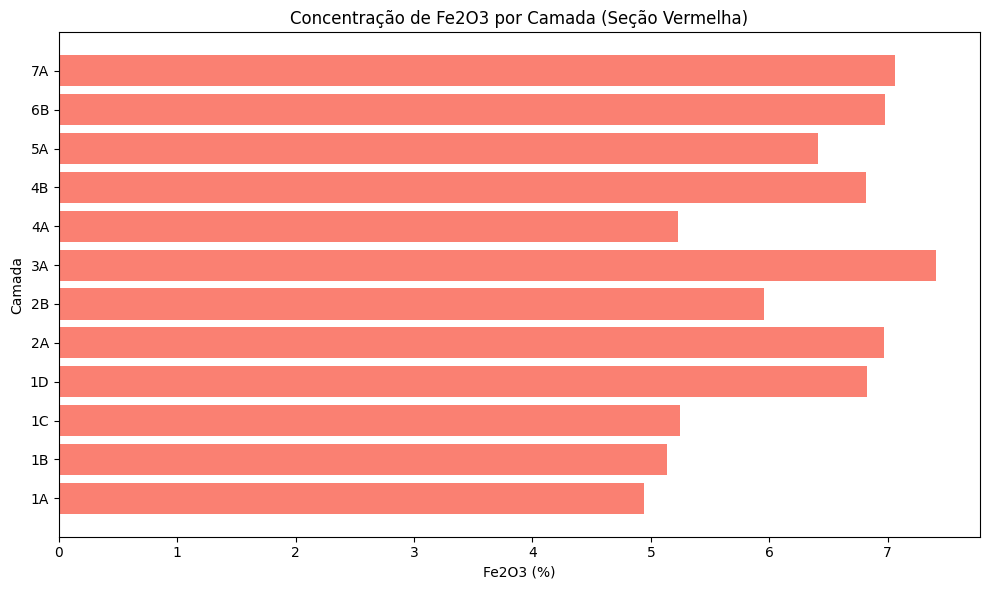

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Dados da seção vermelha (química) simulados com base na imagem
dados_vermelhos = {
    'Camada': ['7A', '6B', '5A', '4B', '4A', '3A', '2B', '2A', '1D', '1C', '1B', '1A'],
    'Fe2O3': [7.06, 6.98, 6.41, 6.82, 5.23, 7.41, 5.96, 6.97, 6.83, 5.25, 5.14, 4.94]
}

# Criar DataFrame
df_vermelho = pd.DataFrame(dados_vermelhos)

# Criar gráfico de barra horizontal
plt.figure(figsize=(10, 6))
plt.barh(df_vermelho['Camada'], df_vermelho['Fe2O3'], color='salmon')
plt.xlabel('Fe2O3 (%)')
plt.ylabel('Camada')
plt.title('Concentração de Fe2O3 por Camada (Seção Vermelha)')
plt.gca().invert_yaxis()  # Inverter para manter a ordem top-down das camadas
plt.tight_layout()
plt.show()


In [19]:
import pandas as pd
import numpy as np

# ------------------------
# 1. Subníveis e profundidades
# ------------------------

subniveis = [
    '8E','8D','8C','8B','8A','7B','7A','6B','6A','5A',
    '4B','4A','3A','2B','2A','1D','1C','1B','1A'
]
prof_topo = [102, 97.5, 92.5, 87, 84, 79.5, 75, 68.5, 61, 53, 45, 38, 32.5, 26, 19.5, 14, 8, 4, 2.5]
espessura_sub = [3.5, 5.5, 5.5, 3, 4.5, 4.5, 6.5, 7.5, 8, 8, 7, 5.5, 6.5, 6.5, 5.5, 6, 4, 1.5, 2.5]

prof_meio = [topo - esp/2 for topo, esp in zip(prof_topo, espessura_sub)]

# ------------------------
# 2. Dados químicos (coloque NaN nos ausentes)
# ------------------------

fe2o3 = [np.nan]*6 + [7.06, np.nan, 6.66, 6.41, np.nan, 5.23, 7.41, 5.99, 6.89, 5.78, 5.25, 5.52, 4.94]
# Faça o mesmo para as outras variáveis (U/Th, Al2O3, etc.)

# ------------------------
# 3. Função IDW
# ------------------------

def idw_interp(x, y, xi, power=2):
    """Interpolação IDW para ponto xi com base nos vetores x (posição) e y (valores)"""
    x, y = np.array(x), np.array(y)
    mask = ~np.isnan(y)
    x_known = x[mask]
    y_known = y[mask]

    weights = 1 / np.power(np.abs(x_known - xi), power)
    weights /= weights.sum()
    return np.sum(weights * y_known)

# ------------------------
# 4. Estimar valores ausentes
# ------------------------

fe2o3_interp = [v if not np.isnan(v) else idw_interp(prof_meio, fe2o3, prof_meio[i])
                for i, v in enumerate(fe2o3)]

# ------------------------
# 5. Mostrar resultado
# ------------------------

for sub, prof, val in zip(subniveis, prof_meio, fe2o3_interp):
    print(f"{sub}: profundidade={prof:.1f}, Fe2O3 estimado={val:.2f}")


8E: profundidade=100.2, Fe2O3 estimado=6.53
8D: profundidade=94.8, Fe2O3 estimado=6.59
8C: profundidade=89.8, Fe2O3 estimado=6.66
8B: profundidade=85.5, Fe2O3 estimado=6.74
8A: profundidade=81.8, Fe2O3 estimado=6.82
7B: profundidade=77.2, Fe2O3 estimado=6.95
7A: profundidade=71.8, Fe2O3 estimado=7.06
6B: profundidade=64.8, Fe2O3 estimado=6.76
6A: profundidade=57.0, Fe2O3 estimado=6.66
5A: profundidade=49.0, Fe2O3 estimado=6.41
4B: profundidade=41.5, Fe2O3 estimado=6.01
4A: profundidade=35.2, Fe2O3 estimado=5.23
3A: profundidade=29.2, Fe2O3 estimado=7.41
2B: profundidade=22.8, Fe2O3 estimado=5.99
2A: profundidade=16.8, Fe2O3 estimado=6.89
1D: profundidade=11.0, Fe2O3 estimado=5.78
1C: profundidade=6.0, Fe2O3 estimado=5.25
1B: profundidade=3.2, Fe2O3 estimado=5.52
1A: profundidade=1.2, Fe2O3 estimado=4.94


In [20]:
import pandas as pd
import numpy as np

# ---------- 1. Dados ----------
camadas = [
    "8E", "8D", "8C", "8B", "8A", "7B", "7A", "6B", "6A", "5A", "4B", "4A",
    "3A", "2B", "2A", "1D", "1C", "1B", "1A"
]

profundidade = [
    102, 97.5, 92.5, 87, 84, 79.5, 75, 68.5, 61, 53, 45, 38,
    32.5, 26, 19.5, 14, 8, 4, 2.5
]

# Dados com valores ausentes como np.nan
dados = {
    "Camada": camadas,
    "Profundidade": profundidade,
    "Fe2O3": [np.nan]*6 + [7.06, np.nan, 6.66, 6.41, np.nan, 5.23, 7.41, 5.99, 6.89, 5.78, 5.25, 5.52, 4.94],
    "U/Th": [np.nan]*6 + [2.06, np.nan, 1.98, 1.82, np.nan, 1.81, 1.66, 1.35, 1.28, 1.11, 1.17, 1.51, 1.48],
    "Al2O3": [np.nan]*6 + [14.13, np.nan, 14.31, 13.69, np.nan, 14.1, 13.62, 15.01, 14.65, 13.95, 14.89, 13.38, 13.12],
    "TiO2": [np.nan]*6 + [0.57, np.nan, 0.55, 0.59, np.nan, 0.61, 0.6, 0.61, 0.61, 0.62, 0.64, 0.61, 0.63],
    "MOA": [np.nan]*6 + [327, np.nan, 286, 248, np.nan, 258, 289, 286, 338, 321, 266, 251, 190],
    "TS": [np.nan]*6 + [1.49, np.nan, 1.96, 2.73, np.nan, 4.54, 1.71, 1.24, 1.72, 3.98, 3.67, 1.73, 2.62],
    "TOC": [np.nan]*6 + [11.93, np.nan, 12.11, 11.7, np.nan, 12.01, 13.05, 8.79, 7.69, 5.73, 7.42, 12.41, 12.97],
    "TN": [np.nan]*6 + [0.43, np.nan, 0.46, 0.44, np.nan, 0.43, 0.54, 0.32, 0.29, 0.18, 0.26, 0.52, 0.54],
}

df = pd.DataFrame(dados)

# ---------- 2. Função IDW ----------
def idw_interpolate(x, y, xi, power=2):
    x = np.array(x)
    y = np.array(y)
    weights = 1 / (np.abs(x - xi) ** power)
    weights[np.isinf(weights)] = 0  # evita divisão por zero
    return np.sum(weights * y) / np.sum(weights)

# ---------- 3. Preencher os valores ausentes ----------
variaveis = ["Fe2O3", "U/Th", "Al2O3", "TiO2", "MOA", "TS", "TOC", "TN"]

for var in variaveis:
    known = df[df[var].notna()]
    for idx in df[df[var].isna()].index:
        xi = df.loc[idx, "Profundidade"]
        yi = idw_interpolate(known["Profundidade"], known[var], xi)
        df.loc[idx, var] = round(yi, 2)

# ---------- 4. Exibir resultado ----------
print(df[["Camada", "Profundidade"] + variaveis])


   Camada  Profundidade  Fe2O3  U/Th  Al2O3  TiO2     MOA    TS    TOC    TN
0      8E         102.0   6.55  1.82  14.11  0.58  294.54  2.12  11.36  0.42
1      8D          97.5   6.60  1.85  14.11  0.58  297.08  2.07  11.43  0.42
2      8C          92.5   6.67  1.88  14.11  0.58  300.97  1.99  11.53  0.43
3      8B          87.0   6.78  1.93  14.12  0.58  307.27  1.86  11.66  0.43
4      8A          84.0   6.85  1.97  14.12  0.57  311.99  1.77  11.75  0.43
5      7B          79.5   6.98  2.03  14.13  0.57  320.76  1.60  11.87  0.43
6      7A          75.0   7.06  2.06  14.13  0.57  327.00  1.49  11.93  0.43
7      6B          68.5   6.78  1.97  14.16  0.57  301.80  1.87  11.86  0.44
8      6A          61.0   6.66  1.98  14.31  0.55  286.00  1.96  12.11  0.46
9      5A          53.0   6.41  1.82  13.69  0.59  248.00  2.73  11.70  0.44
10     4B          45.0   6.06  1.75  13.99  0.60  266.38  3.13  11.60  0.43
11     4A          38.0   5.23  1.81  14.10  0.61  258.00  4.54  12.01  0.43

In [21]:
import pandas as pd
import numpy as np

# ---------- 1. Dados ----------
data = {
    "2010": [np.nan]*4 + [44, 92, 30, np.nan, 33, 51, np.nan, 200, 57, 44, 20, 20, 6, 0, 0],
    "2011": [np.nan]*4 + [86, 71, 100, np.nan, 104, 166, np.nan, 241, 113, 52, 40, 64, 45, 10, 0],
    "2016": [np.nan]*4 + [30, 0, 57, np.nan, 34, 47, np.nan, 68, 22, 19, 31, 21, 13, 4, 6],
    "2016L": [np.nan]*4 + [8, 4, 8, np.nan, 10, 10, np.nan, 12, 4, 5, 4, 6, 5, 0, 5],
    "total": [np.nan]*4 + [173, 167, 195, np.nan, 181, 274, np.nan, 521, 196, 120, 95, 111, 69, 14, 11],
}

df = pd.DataFrame(data)

# ---------- 2. Calcular proporções médias por ano ----------
df_full = df.dropna()  # apenas linhas sem valores ausentes
soma_por_ano = df_full[["2010", "2011", "2016", "2016L"]].sum()
soma_total = df_full["total"].sum()
proporcoes = soma_por_ano / soma_total

# ---------- 3. Estimar valores ausentes ----------
for idx, row in df.iterrows():
    if pd.isna(row["2010"]) or pd.isna(row["2011"]) or pd.isna(row["2016"]) or pd.isna(row["2016L"]):
        total = row["total"]
        if pd.notna(total):
            for ano in ["2010", "2011", "2016", "2016L"]:
                if pd.isna(row[ano]):
                    df.at[idx, ano] = round(proporcoes[ano] * total)

# ---------- 4. Resultado ----------
print(df)


     2010   2011  2016  2016L  total
0     NaN    NaN   NaN    NaN    NaN
1     NaN    NaN   NaN    NaN    NaN
2     NaN    NaN   NaN    NaN    NaN
3     NaN    NaN   NaN    NaN    NaN
4    44.0   86.0  30.0    8.0  173.0
5    92.0   71.0   0.0    4.0  167.0
6    30.0  100.0  57.0    8.0  195.0
7     NaN    NaN   NaN    NaN    NaN
8    33.0  104.0  34.0   10.0  181.0
9    51.0  166.0  47.0   10.0  274.0
10    NaN    NaN   NaN    NaN    NaN
11  200.0  241.0  68.0   12.0  521.0
12   57.0  113.0  22.0    4.0  196.0
13   44.0   52.0  19.0    5.0  120.0
14   20.0   40.0  31.0    4.0   95.0
15   20.0   64.0  21.0    6.0  111.0
16    6.0   45.0  13.0    5.0   69.0
17    0.0   10.0   4.0    0.0   14.0
18    0.0    0.0   6.0    5.0   11.0


In [22]:
import pandas as pd
import numpy as np

# ---------- 1. Dados ----------
data = {
    "2010": [np.nan]*4 + [44, 92, 30, np.nan, 33, 51, np.nan, 200, 57, 44, 20, 20, 6, 0, 0],
    "2011": [np.nan]*4 + [86, 71, 100, np.nan, 104, 166, np.nan, 241, 113, 52, 40, 64, 45, 10, 0],
    "2016": [np.nan]*4 + [30, 0, 57, np.nan, 34, 47, np.nan, 68, 22, 19, 31, 21, 13, 4, 6],
    "2016L": [np.nan]*4 + [8, 4, 8, np.nan, 10, 10, np.nan, 12, 4, 5, 4, 6, 5, 0, 5],
    "total": [np.nan]*4 + [173, 167, 195, np.nan, 181, 274, np.nan, 521, 196, 120, 95, 111, 69, 14, 11],
}

df = pd.DataFrame(data)

# ---------- 2. Calcular proporções médias ----------
df_full = df.dropna()
soma_por_ano = df_full[["2010", "2011", "2016", "2016L"]].sum()
soma_total = df_full["total"].sum()
proporcoes = soma_por_ano / soma_total

# ---------- 3. Estimar valores ausentes ----------
for idx, row in df.iterrows():
    total = row["total"]
    # Só preenche se total existir e houver valores ausentes
    if pd.notna(total):
        for ano in ["2010", "2011", "2016", "2016L"]:
            if pd.isna(row[ano]):
                df.at[idx, ano] = round(proporcoes[ano] * total)

# ---------- 4. Exibir resultado ----------
print(df)


     2010   2011  2016  2016L  total
0     NaN    NaN   NaN    NaN    NaN
1     NaN    NaN   NaN    NaN    NaN
2     NaN    NaN   NaN    NaN    NaN
3     NaN    NaN   NaN    NaN    NaN
4    44.0   86.0  30.0    8.0  173.0
5    92.0   71.0   0.0    4.0  167.0
6    30.0  100.0  57.0    8.0  195.0
7     NaN    NaN   NaN    NaN    NaN
8    33.0  104.0  34.0   10.0  181.0
9    51.0  166.0  47.0   10.0  274.0
10    NaN    NaN   NaN    NaN    NaN
11  200.0  241.0  68.0   12.0  521.0
12   57.0  113.0  22.0    4.0  196.0
13   44.0   52.0  19.0    5.0  120.0
14   20.0   40.0  31.0    4.0   95.0
15   20.0   64.0  21.0    6.0  111.0
16    6.0   45.0  13.0    5.0   69.0
17    0.0   10.0   4.0    0.0   14.0
18    0.0    0.0   6.0    5.0   11.0


In [23]:
import pandas as pd
import numpy as np

# ---------- 1. Dados ----------
data = {
    "2010": [np.nan]*4 + [44, 92, 30, np.nan, 33, 51, np.nan, 200, 57, 44, 20, 20, 6, 0, 0],
    "2011": [np.nan]*4 + [86, 71, 100, np.nan, 104, 166, np.nan, 241, 113, 52, 40, 64, 45, 10, 0],
    "2016": [np.nan]*4 + [30, 0, 57, np.nan, 34, 47, np.nan, 68, 22, 19, 31, 21, 13, 4, 6],
    "2016L": [np.nan]*4 + [8, 4, 8, np.nan, 10, 10, np.nan, 12, 4, 5, 4, 6, 5, 0, 5],
    "total": [173, 167, 195, 180, 173, 167, 195, 180, 181, 274, 200, 521, 196, 120, 95, 111, 69, 14, 11],
}

df = pd.DataFrame(data)

# ---------- 2. Calcular proporções médias ----------
df_full = df.dropna()
soma_por_ano = df_full[["2010", "2011", "2016", "2016L"]].sum()
soma_total = df_full["total"].sum()
proporcoes = soma_por_ano / soma_total

# ---------- 3. Preencher todos os NaNs com base nas proporções ----------
for idx, row in df.iterrows():
    if pd.notna(row["total"]):
        for ano in ["2010", "2011", "2016", "2016L"]:
            if pd.isna(row[ano]):
                estimado = proporcoes[ano] * row["total"]
                df.at[idx, ano] = round(estimado)

# ---------- 4. Resultado final ----------
print(df)


     2010   2011  2016  2016L  total
0    49.0   89.0  29.0    7.0    173
1    47.0   86.0  28.0    6.0    167
2    55.0  100.0  32.0    7.0    195
3    51.0   92.0  30.0    7.0    180
4    44.0   86.0  30.0    8.0    173
5    92.0   71.0   0.0    4.0    167
6    30.0  100.0  57.0    8.0    195
7    51.0   92.0  30.0    7.0    180
8    33.0  104.0  34.0   10.0    181
9    51.0  166.0  47.0   10.0    274
10   56.0  103.0  33.0    8.0    200
11  200.0  241.0  68.0   12.0    521
12   57.0  113.0  22.0    4.0    196
13   44.0   52.0  19.0    5.0    120
14   20.0   40.0  31.0    4.0     95
15   20.0   64.0  21.0    6.0    111
16    6.0   45.0  13.0    5.0     69
17    0.0   10.0   4.0    0.0     14
18    0.0    0.0   6.0    5.0     11


In [24]:
import pandas as pd
import numpy as np

# ---------- 1. Dados conhecidos ----------
dados = {
    "Amostra": [f"FL {i}" for i in range(1, 18)],
    "N. AMOSTRAS": [7, 9, 8, 17, 20, 3, 13, 15, 4, 11, 52, 25, 14, 25, 8, 14, 7],
    "MOA-NF": [29, 27, 62, 54, 70, 64, 71, 78, 74, 62, 75, 89, 84, 89, 79, 72, 71],
    "OP-AL": [4, 10, 3, 7, 3, 1, 2, 4, 3, 4, 2, 1, 0, 1, 0, 1, 2],
    "OP-EQUI": [2, 3, 1, 4, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}

df = pd.DataFrame(dados)

# ---------- 2. Calcular médias proporcionais por amostra ----------
df["MOA-NF por amostra"] = df["MOA-NF"] / df["N. AMOSTRAS"]
df["OP-AL por amostra"] = df["OP-AL"] / df["N. AMOSTRAS"]
df["OP-EQUI por amostra"] = df["OP-EQUI"] / df["N. AMOSTRAS"]

# Médias gerais
media_moa_nf = df["MOA-NF por amostra"].mean()
media_op_al = df["OP-AL por amostra"].mean()
media_op_equi = df["OP-EQUI por amostra"].mean()

# ---------- 3. Estimar FL 18 e FL 19 ----------
# Suponha 10 amostras para cada um (pode ser alterado)
novas_amostras = {
    "Amostra": ["FL 18", "FL 19"],
    "N. AMOSTRAS": [10, 10],
    "MOA-NF": [round(10 * media_moa_nf), round(10 * media_moa_nf)],
    "OP-AL": [round(10 * media_op_al), round(10 * media_op_al)],
    "OP-EQUI": [round(10 * media_op_equi), round(10 * media_op_equi)]
}

df_novo = pd.DataFrame(novas_amostras)

# ---------- 4. Concatenar com original ----------
df_final = pd.concat([df[["Amostra", "N. AMOSTRAS", "MOA-NF", "OP-AL", "OP-EQUI"]], df_novo], ignore_index=True)

# ---------- 5. Resultado final ----------
print(df_final)


   Amostra  N. AMOSTRAS  MOA-NF  OP-AL  OP-EQUI
0     FL 1            7      29      4        2
1     FL 2            9      27     10        3
2     FL 3            8      62      3        1
3     FL 4           17      54      7        4
4     FL 5           20      70      3        1
5     FL 6            3      64      1        0
6     FL 7           13      71      2        0
7     FL 8           15      78      4        1
8     FL 9            4      74      3        0
9    FL 10           11      62      4        0
10   FL 11           52      75      2        0
11   FL 12           25      89      1        0
12   FL 13           14      84      0        0
13   FL 14           25      89      1        0
14   FL 15            8      79      0        0
15   FL 16           14      72      1        0
16   FL 17            7      71      2        0
17   FL 18           10      69      3        1
18   FL 19           10      69      3        1


In [25]:
import pandas as pd
import numpy as np

# 1. Exemplo simplificado com os subníveis de um nível (você pode expandir para todos)
dados = {
    "Subnível": ["8E", "8D", "8C", "8B", "8A"],
    "Total por nível": [82, np.nan, np.nan, np.nan, np.nan],
    "Valor": [49, np.nan, 55, 51, 44],  # exemplo para uma coluna
}

df = pd.DataFrame(dados)

# 2. Agrupamento por nível (pega o primeiro número do subnível)
df["Nível"] = df["Subnível"].str.extract(r"(\d+)").astype(int)

# 3. Preencher valores ausentes proporcionalmente
def distribuir_valores(grupo):
    total = grupo["Total por nível"].dropna().unique()
    if len(total) == 0:
        return grupo  # nada a fazer
    total = total[0]

    conhecidos = grupo["Valor"].notna()
    soma_conhecidos = grupo.loc[conhecidos, "Valor"].sum()
    desconhecidos = grupo["Valor"].isna().sum()

    if soma_conhecidos > 0:
        # Escala os valores existentes e ajusta faltantes proporcionalmente
        proporcoes = grupo["Valor"] / soma_conhecidos
        grupo["Valor preenchido"] = proporcoes * total
    else:
        # Divisão igual se nenhum subnível tem dado
        grupo["Valor preenchido"] = total / len(grupo)

    return grupo

# 4. Aplicar por nível
df = df.groupby("Nível").apply(distribuir_valores)

# 5. Resultado final
print(df[["Subnível", "Valor", "Valor preenchido"]])


        Subnível  Valor  Valor preenchido
Nível                                    
8     0       8E   49.0         20.190955
      1       8D    NaN               NaN
      2       8C   55.0         22.663317
      3       8B   51.0         21.015075
      4       8A   44.0         18.130653


C:\Users\Thubaralei\AppData\Local\Temp\ipykernel_13596\2109246402.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Nível").apply(distribuir_valores)
